In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [2]:
!pip install -q opencv-python-headless scikit-image matplotlib tqdm
print("✅ Packages installed!")

✅ Packages installed!


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:",   torch.cuda.is_available())

if torch.cuda.is_available():
    print("✅ GPU name:", torch.cuda.get_device_name(0))
else:
    print("❌ No GPU!")
    print("   Go to Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.11.0+cu128
GPU available: True
✅ GPU name: Tesla T4


In [ ]:
from google.colab import files

print("Upload your kaggle.json file")
files.upload()

import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

print("✅ Kaggle configured!")

Upload your kaggle.json file


Saving kaggle.json to kaggle.json
✅ Kaggle configured!


In [ ]:
import os

os.makedirs("/content/UIEB/raw", exist_ok=True)
os.makedirs("/content/UIEB/reference", exist_ok=True)

# Download raw images
print("Downloading raw images...")
!kaggle datasets download -d larjeck/uieb-dataset-raw --path /content/UIEB/raw

# Download reference images
print("Downloading reference images...")
!kaggle datasets download -d larjeck/uieb-dataset-reference --path /content/UIEB/reference

print("✅ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/larjeck/uieb-dataset-raw
License(s): apache-2.0
100% 634M/634M [00:08<00:00, 76.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/larjeck/uieb-dataset-reference
License(s): apache-2.0
100% 785M/785M [00:06<00:00, 122MB/s]

✅ Download complete!


In [ ]:
import zipfile
import os

# Extract raw
print("Extracting raw...")
zip_files = [f for f in os.listdir("/content/UIEB/raw") if f.endswith(".zip")]
for z in zip_files:
    with zipfile.ZipFile(f"/content/UIEB/raw/{z}", 'r') as zf:
        zf.extractall("/content/UIEB/raw")
print("✅ Raw extracted!")

# Extract reference
print("Extracting reference...")
zip_files = [f for f in os.listdir("/content/UIEB/reference") if f.endswith(".zip")]
for z in zip_files:
    with zipfile.ZipFile(f"/content/UIEB/reference/{z}", 'r') as zf:
        zf.extractall("/content/UIEB/reference")
print("✅ Reference extracted!")

# Check folders
print("\nChecking folders...")
for item in os.listdir("/content/UIEB/raw"):
    path = os.path.join("/content/UIEB/raw", item)
    if os.path.isdir(path):
        print(f"  raw/{item}/ → {len(os.listdir(path))} images")

for item in os.listdir("/content/UIEB/reference"):
    path = os.path.join("/content/UIEB/reference", item)
    if os.path.isdir(path):
        print(f"  reference/{item}/ → {len(os.listdir(path))} images")

Extracting raw...
✅ Raw extracted!
Extracting reference...
✅ Reference extracted!

Checking folders...
  raw/raw-890/ → 890 images
  reference/reference-890/ → 890 images


In [ ]:
import shutil
import os

print("Saving dataset to Google Drive...")
print("One time only — never download again!")

os.makedirs("/content/drive/MyDrive/UIEB", exist_ok=True)

# Find raw folder name automatically
raw_folder = None
for item in os.listdir("/content/UIEB/raw"):
    if os.path.isdir(os.path.join("/content/UIEB/raw", item)):
        raw_folder = item
        break

# Find reference folder name automatically
ref_folder = None
for item in os.listdir("/content/UIEB/reference"):
    if os.path.isdir(os.path.join("/content/UIEB/reference", item)):
        ref_folder = item
        break

print(f"Raw folder name:       {raw_folder}")
print(f"Reference folder name: {ref_folder}")

# Save raw to Drive
if not os.path.exists("/content/drive/MyDrive/UIEB/raw-890"):
    shutil.copytree(
        f"/content/UIEB/raw/{raw_folder}",
        "/content/drive/MyDrive/UIEB/raw-890"
    )
    print("✅ Raw images saved!")
else:
    print("✅ Raw already in Drive!")

# Save reference to Drive
if not os.path.exists("/content/drive/MyDrive/UIEB/reference-890"):
    shutil.copytree(
        f"/content/UIEB/reference/{ref_folder}",
        "/content/drive/MyDrive/UIEB/reference-890"
    )
    print("✅ Reference images saved!")
else:
    print("✅ Reference already in Drive!")

print("\n🎉 Dataset saved to Google Drive!")
print("   Next session — no download needed!")

Saving dataset to Google Drive...
One time only — never download again!
Raw folder name:       raw-890
Reference folder name: reference-890
✅ Raw images saved!
✅ Reference images saved!

🎉 Dataset saved to Google Drive!
   Next session — no download needed!


In [4]:
import os

raw_dir = "/content/drive/MyDrive/UIEB/raw-890"
ref_dir = "/content/drive/MyDrive/UIEB/reference-890"

# Verify
if os.path.exists(raw_dir):
    print(f"✅ Raw images:       {len(os.listdir(raw_dir))} images")
else:
    print("❌ Raw folder not found!")

if os.path.exists(ref_dir):
    print(f"✅ Reference images: {len(os.listdir(ref_dir))} images")
else:
    print("❌ Reference folder not found!")

✅ Raw images:       890 images
✅ Reference images: 890 images


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class UnderwaterDataset(Dataset):
    def __init__(self, raw_dir, ref_dir, img_size=256):
        self.raw_dir = raw_dir
        self.ref_dir = ref_dir

        self.images = sorted([
            f for f in os.listdir(raw_dir)
            if f.endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])

        # NO normalization — just resize and convert to tensor
        # Values stay in 0.0 to 1.0 range
        # Matches our Sigmoid output perfectly!
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
            # removed Normalize intentionally!
        ])

        print(f"✅ Dataset created!")
        print(f"   Total pairs: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        raw_img = Image.open(
            os.path.join(self.raw_dir, img_name)
        ).convert("RGB")

        ref_img = Image.open(
            os.path.join(self.ref_dir, img_name)
        ).convert("RGB")

        return self.transform(raw_img), self.transform(ref_img)

In [6]:
# Create dataset
full_dataset = UnderwaterDataset(raw_dir, ref_dir, img_size=256)

# Split 80/20
total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ DataLoaders created!")
print(f"   Train: {train_size} images")
print(f"   Val:   {val_size} images")

✅ Dataset created!
   Total pairs: 890
✅ DataLoaders created!
   Train: 712 images
   Val:   178 images


In [7]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # KEY: adds input back to output
        # learns only the correction needed
        return self.relu(x + self.block(x))


class UnderwaterNet(nn.Module):
    """
    Residual learning approach:
    Instead of learning the full output image,
    model learns only the CORRECTION to apply.

    output = input + correction
    correction = small adjustments to fix:
      - blue/green color cast
      - haze
      - low contrast
    """
    def __init__(self):
        super().__init__()

        # Feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Residual blocks — learn corrections
        self.res_blocks = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
        )

        # Reconstruction
        self.reconstruct = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1),
        )

    def forward(self, x):
        # Extract features
        feat = self.features(x)

        # Learn residual corrections
        res = self.res_blocks(feat)

        # Get correction map
        correction = self.reconstruct(res)

        # KEY LINE: add correction to original input!
        # output = input + learned correction
        # Tanh keeps correction in -1 to 1 range
        output = x + torch.tanh(correction) * 0.3

        # Clamp to valid range
        return torch.clamp(output, 0, 1)


model = UnderwaterNet().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Residual UnderwaterNet created!")
print(f"   Device:     {device}")
print(f"   Parameters: {total_params:,}")
print(f"   Approach:   Residual learning")

✅ Residual UnderwaterNet created!
   Device:     cuda
   Parameters: 354,499
   Approach:   Residual learning


In [8]:
import torch.optim as optim

def combined_loss(output, target):
    # Simple L1 loss works best for residual learning
    l1 = nn.L1Loss()(output, target)

    # SSIM inspired loss — structural similarity
    # forces model to preserve image structure
    mean_out = output.mean(dim=[2,3], keepdim=True)
    mean_tgt = target.mean(dim=[2,3], keepdim=True)

    std_out = ((output - mean_out) ** 2).mean(dim=[2,3])
    std_tgt = ((target - mean_tgt) ** 2).mean(dim=[2,3])

    covar = ((output - mean_out) * (target - mean_tgt)).mean(dim=[2,3])

    ssim_loss = 1 - (
        (2 * covar + 1e-8) /
        (std_out + std_tgt + 1e-8)
    ).mean()

    return 0.7 * l1 + 0.3 * ssim_loss

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

print("✅ Loss and optimizer ready!")
print("   Loss: L1 + SSIM")
print("   LR:   0.001")

✅ Loss and optimizer ready!
   Loss: L1 + SSIM
   LR:   0.001


In [10]:
from tqdm import tqdm

NUM_EPOCHS    = 30
train_losses  = []
val_losses    = []
best_val_loss = float('inf')

os.makedirs(
    "/content/drive/MyDrive/underwater_weights",
    exist_ok=True
)

print(f"Starting training...")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Device: {device}")
print("-" * 50)

for epoch in range(NUM_EPOCHS):

    # TRAIN
    model.train()
    train_loss = 0.0

    for raw_imgs, ref_imgs in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Train"
    ):
        raw_imgs = raw_imgs.to(device)
        ref_imgs = ref_imgs.to(device)

        optimizer.zero_grad()
        output = model(raw_imgs)
        loss   = combined_loss(output, ref_imgs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)

    # VALIDATE
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for raw_imgs, ref_imgs in tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{NUM_EPOCHS} Val"
        ):
            raw_imgs = raw_imgs.to(device)
            ref_imgs = ref_imgs.to(device)
            output   = model(raw_imgs)
            loss     = combined_loss(output, ref_imgs)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step()

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train: {avg_train:.4f} | "
          f"Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/underwater_weights/underwater_best.pth"
        )
        print(f"  ✅ Saved! Val: {best_val_loss:.4f}")

print("\n🎉 Training complete!")
print(f"   Best val loss: {best_val_loss:.4f}")

Starting training...
Epochs: 30
Device: cuda
--------------------------------------------------


Epoch 1/30 Val: 100%|██████████| 23/23 [00:38<00:00,  1.69s/it]


Epoch  1/30 | Train: 0.1102 | Val: 0.1107
  ✅ Saved! Val: 0.1107


Epoch 2/30 Val: 100%|██████████| 23/23 [00:09<00:00,  2.32it/s]


Epoch  2/30 | Train: 0.1013 | Val: 0.1074
  ✅ Saved! Val: 0.1074


...

Epoch 28/30 | Train: 0.0846 | Val: 0.0856
  ✅ Saved! Val: 0.0856


Epoch 29/30 Val: 100%|██████████| 23/23 [00:10<00:00,  2.17it/s]


Epoch 29/30 | Train: 0.0846 | Val: 0.0857


Epoch 30/30 Val: 100%|██████████| 23/23 [00:10<00:00,  2.22it/s]

Epoch 30/30 | Train: 0.0845 | Val: 0.0854
  ✅ Saved! Val: 0.0854

🎉 Training complete!
   Best val loss: 0.0854


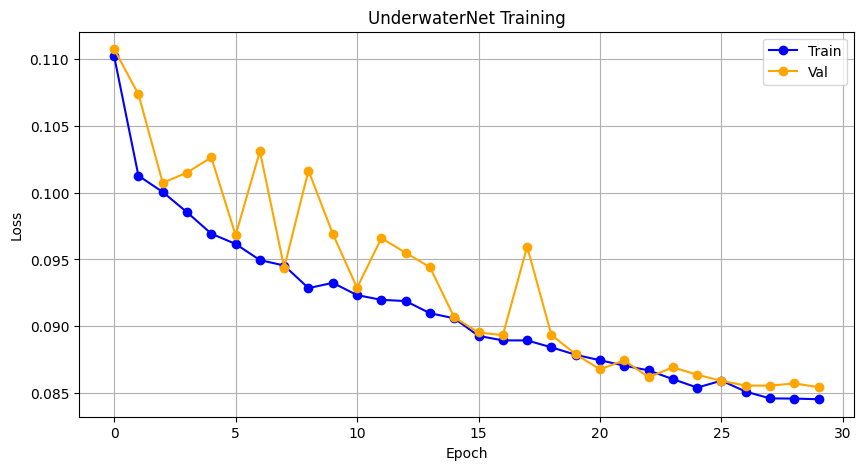

Start loss:  0.1102
End loss:    0.0845
Improvement: 23.3%


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train', color='blue',   marker='o')
plt.plot(val_losses,   label='Val',   color='orange', marker='o')
plt.title('UnderwaterNet Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Start loss:  {train_losses[0]:.4f}")
print(f"End loss:    {train_losses[-1]:.4f}")
print(f"Improvement: {((train_losses[0]-train_losses[-1])/train_losses[0]*100):.1f}%")

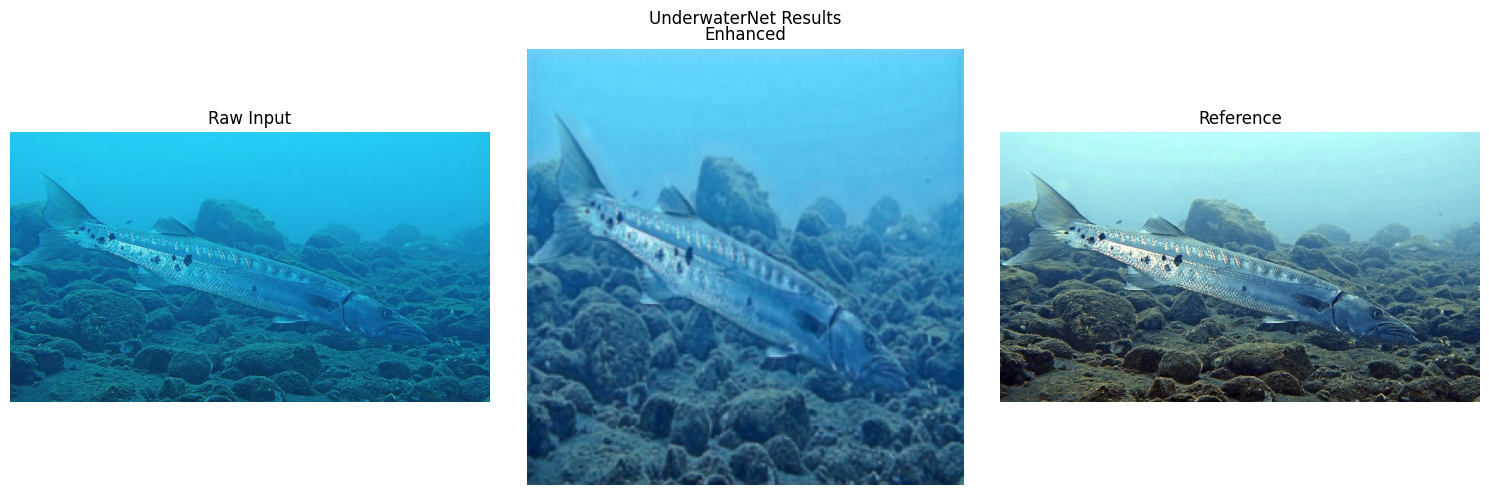

In [13]:
import numpy as np
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/underwater_weights/underwater_best.pth",
        map_location=device
    )
)
model.eval()

# Show only 1 image
sample_name = sorted(os.listdir(raw_dir))[0]
raw_img = Image.open(
    os.path.join(raw_dir, sample_name)
).convert("RGB")
ref_img = Image.open(
    os.path.join(ref_dir, sample_name)
).convert("RGB")

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

tensor = transform(raw_img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(tensor)

output = output.squeeze(0).cpu().numpy()
output = np.transpose(output, (1, 2, 0))
output = np.clip(output, 0, 1)
output = (output * 255).astype(np.uint8)

# Show 1 row only
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_img)
axes[0].set_title("Raw Input")
axes[0].axis('off')

axes[1].imshow(Image.fromarray(output))
axes[1].set_title("Enhanced")
axes[1].axis('off')

axes[2].imshow(ref_img)
axes[2].set_title("Reference")
axes[2].axis('off')

plt.suptitle("UnderwaterNet Results")
plt.tight_layout()
plt.show()

In [14]:
from google.colab import files

print("Downloading weights...")
files.download(
    "/content/drive/MyDrive/underwater_weights/underwater_best.pth"
)
print("✅ Done!")
print("Save to: backend/weights/underwater_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!
Save to: backend/weights/underwater_best.pth
